# v2-3 training — v4-1-1dce architecture with IFI clip [0°, 40°]

Inline architecture builder. Same graph as the original `v4-1-1dce` reference (no `ClipLayer`, plain `DisplacementLayer`, `NewmarkActivation(threshold=2.0)`), with one structural change: the **internal friction angle is hard-clipped to [0°, 40°]** via a `Lambda(tf.clip_by_value)` immediately after `InternalFrictionLayer`. The lower bound at 0° is effectively a no-op (sigmoid is already non-negative); the operative constraint is the 40° upper bound.

- 18 numerics + `type` (string) + `PGA1_max` (physics input) → 20 inputs
- 9-block MLP: `Sus_0(64)` then `[32,64,8,64,32,8,32,8]` each with BN + LeakyReLU(0.2)
- Geotech head: `Dense(2)` + LeakyReLU → `CohesionLayer` / `InternalFrictionLayer` → `Lambda(clip to [0°,40°] radians)`
- Physics: `DisplacementLayer([coh, ifi_clipped, Slope_mean, PGA1_max, BUK_mean])` → LeakyReLU → `NewmarkActivation(threshold=2.0)`
- Loss `DiceCrossEntropyLoss`, Adam lr=1e-5, 10-fold StratifiedKFold, class_weight {0:1, 1:5}, EarlyStopping(patience=5, monitor='loss')

Checkpoints write to `v4-1-1dce-repro-ifi-clip-0-40/` so the no-clip baseline at `v4-1-1dce-repro/` and the [25°,45°] variant at `v4-1-1dce-repro-ifi-clip-25-45/` remain intact for comparison.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import importlib
from py_files import GallenModel_v1, Landslidev2_Old, data, metrics
importlib.reload(GallenModel_v1)
importlib.reload(Landslidev2_Old)
importlib.reload(data)
importlib.reload(metrics)

import numpy as np
import pandas as pd
import geopandas as gpd
import tensorflow as tf
from tensorflow.keras import layers, Model
import sklearn
from sklearn.model_selection import StratifiedKFold
from matplotlib import pyplot as plt

from py_files.data import dataframe_to_dataset, NormalizationLayer, CategoricalEncoderLayer
from py_files.GallenModel_v1 import (
    CohesionLayer,
    InternalFrictionLayer,
    IFIClipLayer,
    DisplacementLayer,
    NewmarkActivation,
)
from py_files.Landslidev2_Old import DiceCrossEntropyLoss
from py_files.metrics import plot_landslide_distribution

In [2]:
# Source-of-truth training data. The same file exists locally at datasets/SU_15_Training1.gpkg;
# we keep the ML-PREP-2025/learn/data path so the manifest matches the original run.
df = gpd.read_file('~/Documents/ml-prep/ML-PREP-2025/learn/data/SU_15_Training1.gpkg')
df.drop(columns=[
    'landslide_probability', 'landslide_preds', 'confusion',
    'sus_pinn_landslide', 'sus_pinn_ground truth', 'ds',
    'cohesion', 'internal_friction',
], inplace=True)
df['type'].head()

0    Undifferentiated
1    Undifferentiated
2    Undifferentiated
3    Undifferentiated
4    Undifferentiated
Name: type, dtype: object

In [3]:
df = df[df['Slope_mean'] >= 10]
df.dropna(subset=list(df.columns), inplace=True)

In [4]:
cols_remove = ['DN', 'BD_mean', 'geometry', 'PGA2_max', 'Soil Type', 'description', 'descriptio']
columns = [c for c in df.columns if c not in cols_remove]
numeric_columns = [c for c in columns if c not in ('landslide', 'type')]
categorical_columns = ['type']
pga_column = 'PGA1_max'
print('columns:', columns)
print('numerics:', numeric_columns)

columns: ['Clay_mean', 'Sand_mean', 'Silt_mean', 'NDVI_mean', 'Est_mean', 'Nrt_mean', 'HorCurv_mean', 'VertCurv_mean', 'Slope_mean', 'Elev_mean', 'SoilThc_mean', 'DistFlt_min', 'LULC_majority', 'TWI_mean', 'PGA1_max', 'Prc_mean', 'Distrv_min', 'distrd_min', 'BUK_mean', 'landslide', 'type']
numerics: ['Clay_mean', 'Sand_mean', 'Silt_mean', 'NDVI_mean', 'Est_mean', 'Nrt_mean', 'HorCurv_mean', 'VertCurv_mean', 'Slope_mean', 'Elev_mean', 'SoilThc_mean', 'DistFlt_min', 'LULC_majority', 'TWI_mean', 'PGA1_max', 'Prc_mean', 'Distrv_min', 'distrd_min', 'BUK_mean']


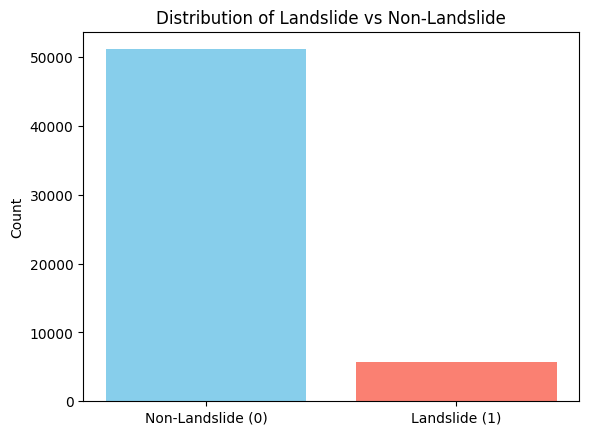

In [5]:
plot_landslide_distribution(df['landslide'].value_counts())

## Architecture builder — IFI clipped to [0°, 40°]

Mirrors the v4-1-1dce graph but applies `tf.clip_by_value(ifi_rad, 0, deg_to_rad(40))` right after `InternalFrictionLayer`. The drifted `LandslideV4` class is bypassed.

In [6]:
import math

MLP_UNITS = [32, 64, 8, 64, 32, 8, 32, 8]  # depth=8; Sus_0 is a separate 64-unit projection
LEAKY_ALPHA = 0.2
NEWMARK_THRESHOLD = 2.0
LEARNING_RATE = 1e-5

IFI_CLIP_DEG = (0.0, 40.0)
IFI_CLIP_RAD = tuple(math.radians(d) for d in IFI_CLIP_DEG)


def build_v411dce_model(train_ds, numeric_cols, categorical_cols, pga_col):
    """Construct the v4-1-1dce PINN graph with a hard clip on IFI."""
    all_inputs = []
    encoded = []
    pga_input = None

    for header in numeric_cols:
        x_in = tf.keras.Input((1,), name=header)
        if header == pga_col:
            pga_input = x_in
            continue
        x_norm = NormalizationLayer(header, train_ds)(x_in)
        all_inputs.append(x_in)
        encoded.append(x_norm)

    for header in categorical_cols:
        x_in = tf.keras.Input((1,), name=header, dtype='string')
        x_enc = CategoricalEncoderLayer(header, train_ds, dtype='string')(x_in)
        all_inputs.append(x_in)
        encoded.append(x_enc)

    if pga_input is None:
        raise ValueError(f"PGA column {pga_col!r} not in numeric_cols")

    by_name = {t.name.split(':')[0]: t for t in all_inputs}
    slope = by_name['Slope_mean']
    bulk_density = by_name['BUK_mean']

    x = layers.concatenate(encoded)
    x = layers.Dense(64, name='Sus_0',
                     kernel_initializer='random_normal',
                     bias_initializer='random_normal')(x)

    for i, units in enumerate(MLP_UNITS, start=1):
        x = layers.Dense(units, name=f'Sus_{i}',
                         kernel_initializer='random_normal',
                         bias_initializer='random_normal')(x)
        x = layers.BatchNormalization()(x)
        x = layers.LeakyReLU(negative_slope=LEAKY_ALPHA)(x)

    x = layers.Dense(2, name='geotechnical_param')(x)
    x = layers.LeakyReLU(negative_slope=LEAKY_ALPHA)(x)

    coh = CohesionLayer()(x)
    ifi = InternalFrictionLayer()(x)
    ifi = IFIClipLayer(IFI_CLIP_RAD[0], IFI_CLIP_RAD[1], name='ifi_clip_0_40')(ifi)

    ds = DisplacementLayer()([coh, ifi, slope, pga_input, bulk_density])
    ds = layers.LeakyReLU(negative_slope=LEAKY_ALPHA)(ds)
    sus = NewmarkActivation(threshold=NEWMARK_THRESHOLD)(ds)

    model = Model(inputs=all_inputs + [pga_input], outputs=sus)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss=DiceCrossEntropyLoss(),
        metrics=[
            tf.keras.metrics.BinaryIoU(target_class_ids=[0, 1], threshold=0.5),
            tf.keras.metrics.AUC(curve='ROC'),
            'accuracy',
        ],
    )
    return model

## 10-fold training loop

Writes `fold-{1..10}-model-0.keras` into `OUTPUT_DIR` (= `v4-1-1dce-repro-ifi-clip-0-40/`). The original Jan 21 v4-1-1dce checkpoints and the prior `v4-1-1dce-repro` / `v4-1-1dce-repro-ifi-clip-25-45` runs are preserved at their own paths.


=== Fold 1/10 ===


2026-05-20 15:22:20.547089: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-20 15:22:20.801399: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-20 15:22:21.288005: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-20 15:22:22.244657: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-20 15:22:24.190133: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


dtype is a string
Epoch 1/200
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.5706 - auc: 0.6968 - binary_io_u: 0.3461 - loss: 1.6135 - val_accuracy: 0.6315 - val_auc: 0.6617 - val_binary_io_u: 0.3785 - val_loss: 1.0363
Epoch 2/200
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6468 - auc: 0.6512 - binary_io_u: 0.3864 - loss: 1.3919 - val_accuracy: 0.7046 - val_auc: 0.6285 - val_binary_io_u: 0.4165 - val_loss: 0.8955
Epoch 3/200
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7141 - auc: 0.6296 - binary_io_u: 0.4200 - loss: 1.1892 - val_accuracy: 0.7604 - val_auc: 0.6193 - val_binary_io_u: 0.4466 - val_loss: 0.7990
Epoch 4/200
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7553 - auc: 0.6294 - binary_io_u: 0.4448 - loss: 1.0907 - val_accuracy: 0.7925 - val_auc: 0.6323 - val_binary_io_u: 0.4681 - val_loss: 0.7377
Epoch 5/200
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7816 - auc: 0.6200 - binary_io_u: 0.4557 - loss: 1.0079 - val_accurac

2026-05-20 15:25:28.937425: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


dtype is a string
Epoch 1/200
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7060 - auc: 0.6692 - binary_io_u: 0.4258 - loss: 1.2233 - val_accuracy: 0.7481 - val_auc: 0.6682 - val_binary_io_u: 0.4481 - val_loss: 0.7868
Epoch 2/200
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7546 - auc: 0.6630 - binary_io_u: 0.4548 - loss: 1.0691 - val_accuracy: 0.7788 - val_auc: 0.6532 - val_binary_io_u: 0.4613 - val_loss: 0.7184
Epoch 3/200
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7916 - auc: 0.6382 - binary_io_u: 0.4707 - loss: 0.9604 - val_accuracy: 0.8071 - val_auc: 0.6426 - val_binary_io_u: 0.4744 - val_loss: 0.6778
Epoch 4/200
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8100 - auc: 0.6230 - binary_io_u: 0.4777 - loss: 0.9211 - val_accuracy: 0.8223 - val_auc: 0.6382 - val_binary_io_u: 0.4828 - val_loss: 0.6646
Epoch 5/200
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8243 - auc: 0.6265 - binary_io_u: 0.4841 - loss: 0.8951 - val_accurac

2026-05-20 15:31:25.345519: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


dtype is a string
Epoch 1/200
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7559 - auc: 0.6813 - binary_io_u: 0.4588 - loss: 1.1205 - val_accuracy: 0.8027 - val_auc: 0.6663 - val_binary_io_u: 0.4811 - val_loss: 0.7113
Epoch 2/200
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 2s 978us/step - accuracy: 0.8028 - auc: 0.6564 - binary_io_u: 0.4804 - loss: 0.9752 - val_accuracy: 0.8221 - val_auc: 0.6366 - val_binary_io_u: 0.4860 - val_loss: 0.6748
Epoch 3/200
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 2s 974us/step - accuracy: 0.8207 - auc: 0.6487 - binary_io_u: 0.4876 - loss: 0.9247 - val_accuracy: 0.8342 - val_auc: 0.6373 - val_binary_io_u: 0.4869 - val_loss: 0.6559
Epoch 4/200
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 2s 979us/step - accuracy: 0.8276 - auc: 0.6323 - binary_io_u: 0.4848 - loss: 0.9023 - val_accuracy: 0.8383 - val_auc: 0.6347 - val_binary_io_u: 0.4847 - val_loss: 0.6504
Epoch 5/200
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 2s 995us/step - accuracy: 0.8332 - auc: 0.6444 - binary_io_u: 0.4937 - loss: 0.9016 - val

2026-05-20 15:41:37.121628: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


dtype is a string
Epoch 1/200
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7084 - auc: 0.6989 - binary_io_u: 0.4320 - loss: 1.2116 - val_accuracy: 0.7588 - val_auc: 0.6730 - val_binary_io_u: 0.4528 - val_loss: 0.7536
Epoch 2/200
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7542 - auc: 0.6453 - binary_io_u: 0.4425 - loss: 1.0324 - val_accuracy: 0.8027 - val_auc: 0.6304 - val_binary_io_u: 0.4660 - val_loss: 0.6709
Epoch 3/200
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 2s 992us/step - accuracy: 0.7933 - auc: 0.6125 - binary_io_u: 0.4581 - loss: 0.9365 - val_accuracy: 0.8282 - val_auc: 0.6182 - val_binary_io_u: 0.4776 - val_loss: 0.6278
Epoch 4/200
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 2s 983us/step - accuracy: 0.8183 - auc: 0.5905 - binary_io_u: 0.4662 - loss: 0.8849 - val_accuracy: 0.8488 - val_auc: 0.6080 - val_binary_io_u: 0.4887 - val_loss: 0.6054
Epoch 5/200
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 2s 979us/step - accuracy: 0.8356 - auc: 0.5874 - binary_io_u: 0.4737 - loss: 0.8511 - val_a

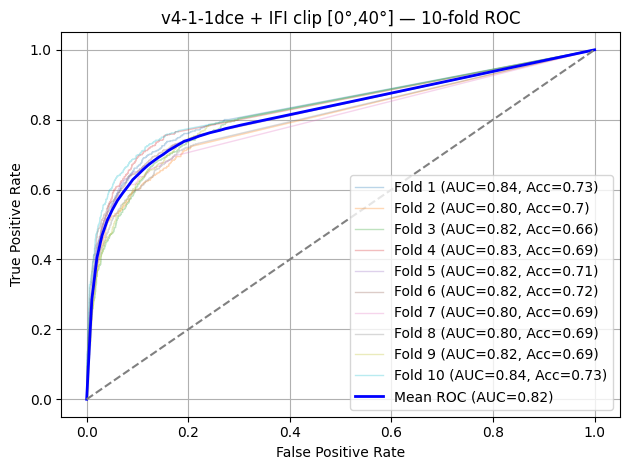

In [7]:
OUTPUT_DIR = Path('/Users/giogonzales/Documents/ml-prep/ML-PREP-2025/learn/trainedWeights/trainedCotabatoPhase7/historical/v4-1-1dce-repro-ifi-clip-0-40')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

EPOCHS = 200
BATCH_SIZE = 128
CLASS_WEIGHT = {0: 1, 1: 5}
N_SPLITS = 10

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

losses_per_fold = []
aucs = []
tprs = []
mean_fpr = np.linspace(0, 1, 100)
predictions = np.zeros(df.shape[0])

for fold, (train_idx, val_idx) in enumerate(skf.split(df, df['landslide']), start=1):
    print(f'\n=== Fold {fold}/{N_SPLITS} ===')
    train_df, val_df = df.iloc[train_idx], df.iloc[val_idx]
    train_ds = dataframe_to_dataset(train_df[columns])
    val_ds = dataframe_to_dataset(val_df[columns], shuffle=False)

    tf.keras.backend.clear_session()
    model = build_v411dce_model(train_ds, numeric_columns, categorical_columns, pga_column)

    ckpt_path = str(OUTPUT_DIR / f'fold-{fold}-model-0.keras')
    ckpt = tf.keras.callbacks.ModelCheckpoint(
        ckpt_path,
        save_best_only=True,
        save_weights_only=False,
        mode='max',
        save_freq='epoch',
        verbose=0,
    )
    early = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)

    hist = model.fit(
        train_ds,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_data=val_ds,
        class_weight=CLASS_WEIGHT,
        callbacks=[early, ckpt],
        verbose=1,
    )
    losses_per_fold.append(hist.history['loss'])

    y_true = val_df['landslide'].to_numpy()
    y_pred = model.predict(val_ds).flatten()
    predictions[val_idx] = y_pred

    fpr, tpr, _ = sklearn.metrics.roc_curve(y_true, y_pred)
    auc = sklearn.metrics.auc(fpr, tpr)
    aucs.append(auc)
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)

    acc = round(sklearn.metrics.balanced_accuracy_score(y_true, y_pred > 0.5), 2)
    plt.plot(fpr, tpr, lw=1, alpha=0.3, label=f'Fold {fold} (AUC={auc:.2f}, Acc={acc})')

mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = sklearn.metrics.auc(mean_fpr, mean_tpr)
plt.plot(mean_fpr, mean_tpr, lw=2, label=f'Mean ROC (AUC={mean_auc:.2f})', color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('v4-1-1dce + IFI clip [0°,40°] — 10-fold ROC')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Sanity check — clip is wired in

Loads fold-4 from this run and confirms the `ifi_clip_0_40` Lambda sits between `internal_friction` and `displacement_layer`, and that downstream predictions never use IFI values outside the bound.

In [ ]:
from tensorflow.keras.models import load_model

REPRO = str(OUTPUT_DIR / 'fold-4-model-0.keras')
m = load_model(REPRO)

# Confirm clip layer is in place
layer_names = [l.name for l in m.layers]
assert 'ifi_clip_0_40' in layer_names, 'IFI clip layer missing'
print('Clip layer present at index', layer_names.index('ifi_clip_0_40'))

# Verify post-clip IFI stays inside [0°, 40°]
clip_out = m.get_layer('ifi_clip_0_40').output
probe = tf.keras.Model(inputs=m.input, outputs=clip_out)
val_ds_probe = dataframe_to_dataset(df.head(5000)[columns], shuffle=False)
ifi_post = probe.predict(val_ds_probe, verbose=0).flatten()
ifi_deg = np.degrees(ifi_post)
print(f'Post-clip IFI (deg): min={ifi_deg.min():.3f}  max={ifi_deg.max():.3f}  mean={ifi_deg.mean():.3f}')
print(f'Within [{IFI_CLIP_DEG[0]}, {IFI_CLIP_DEG[1]}]: {((ifi_deg >= IFI_CLIP_DEG[0]) & (ifi_deg <= IFI_CLIP_DEG[1])).all()}')
print(f'Total trainable params: {m.count_params()}')

## Susceptibility map — pick any fold

Loads a fold from `OUTPUT_DIR` and plots predicted susceptibility on the `SU_15_Validation1` set. Default is fold 4 to match the existing validation notebook.

preds: min=0.1326  max=1.0000  mean=0.3227


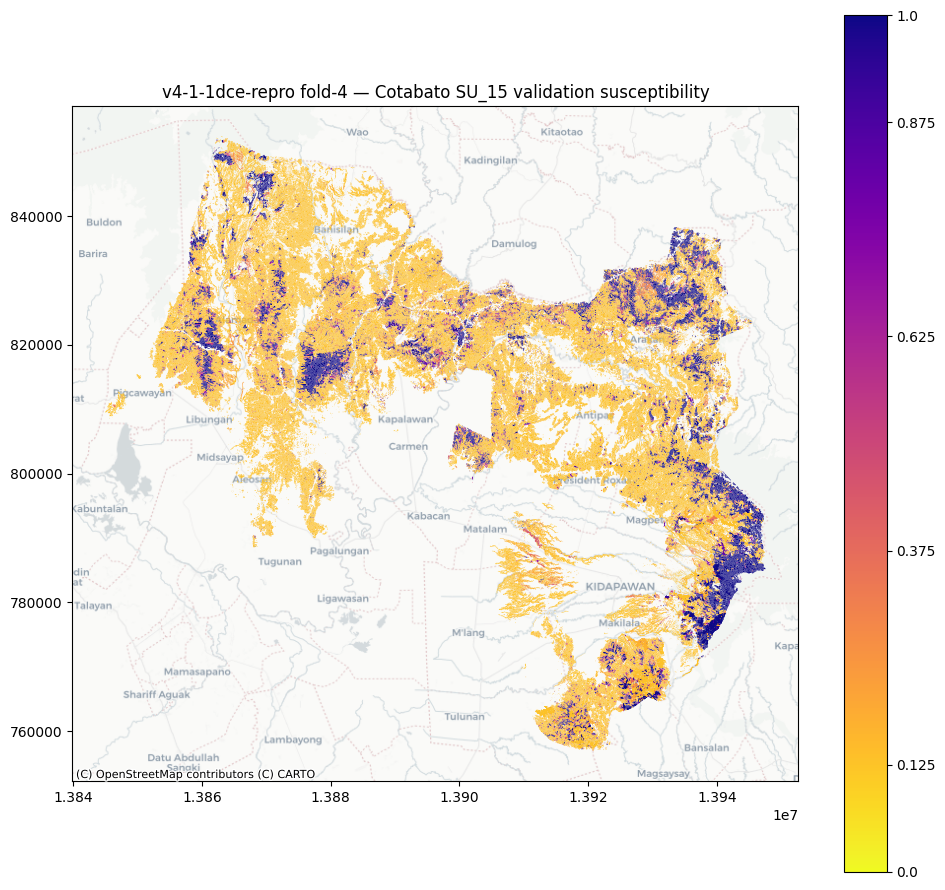

In [ ]:
import matplotlib.colors as mcolors
import contextily as cx
from tensorflow.keras.models import load_model

FOLD = 4

validation_df = gpd.read_file('~/Documents/ml-prep/ML-PREP-2025/learn/data/SU_15_Validation1.gpkg')
validation_df.drop(columns=[
    'landslide_probability', 'landslide_preds', 'confusion',
    'sus_pinn_landslide', 'sus_pinn_ground truth', 'ds',
    'cohesion', 'internal_friction', 'descriptio',
], inplace=True)
validation_df = validation_df[validation_df['Slope_mean'] >= 10]
validation_df.dropna(subset=list(validation_df.columns), inplace=True)

feature_cols = [c for c in validation_df.columns if c not in (
    'descriptio', 'predicted_susceptibility', 'DN', 'BD_mean',
    'geometry', 'PGA2_max', 'Soil Type', 'description',
)]
val_ds = dataframe_to_dataset(validation_df[feature_cols], shuffle=False)

fold_model = load_model(str(OUTPUT_DIR / f'fold-{FOLD}-model-0.keras'))
preds = fold_model.predict(val_ds, verbose=0).flatten()
print(f'preds: min={preds.min():.4f}  max={preds.max():.4f}  mean={preds.mean():.4f}')

gdf = validation_df.to_crs(epsg=3857).copy()
gdf['predicted_susceptibility'] = preds
norm = mcolors.Normalize(vmin=0, vmax=1.0)
fig, ax = plt.subplots(1, 1, figsize=(10, 9))
gdf.plot(column='predicted_susceptibility', cmap='plasma_r', ax=ax, norm=norm)
sm = plt.cm.ScalarMappable(cmap='plasma_r', norm=norm)
cbar = fig.colorbar(sm, ax=ax)
cbar.set_ticks([0.0, 0.125, 0.375, 0.625, 0.875, 1.0])
cbar.set_ticklabels(['0.0', '0.125', '0.375', '0.625', '0.875', '1.0'])
ax.set_title(f'v4-1-1dce-repro fold-{FOLD} \u2014 Cotabato SU_15 validation susceptibility')
cx.add_basemap(ax, crs=gdf.crs.to_string(), source=cx.providers.CartoDB.Positron)
plt.tight_layout()
plt.show()

In [ ]:
import os 
# Load all 5 fold models and collect predictions
fold_susceptibilities = []
fold_cohesions = []
fold_ifis = []
fold_fos_list = []

for fold in range(1, 6):
    fold_path = str(OUTPUT_DIR / f'fold-{fold}-model-0.keras')
    if not os.path.exists(fold_path):
        print(f"  Fold {fold} not found at {fold_path}, skipping")
        continue
    fold_model = load_model(fold_path, custom_objects={"NewmarkActivation": NewmarkActivation})

    predicted_sus = fold_model.predict(val_ds)

    print(predicted_sus.shape)

    fold_susceptibilities.append(predicted_sus)

    coh_m = tf.keras.Model(inputs=fold_model.inputs, outputs=fold_model.get_layer("cohesion_layer").output)
    fold_cohesions.append(coh_m.predict(val_ds).flatten())

    ifi_m = tf.keras.Model(inputs=fold_model.inputs, outputs=fold_model.get_layer("internal_friction").output)
    fold_ifis.append(ifi_m.predict(val_ds).flatten())


    del fold_model
    tf.keras.backend.clear_session()

print(f"Loaded {len(fold_susceptibilities)} fold models")

7534/7534 ━━━━━━━━━━━━━━━━━━━━ 4s 521us/step
(241062, 1)
7534/7534 ━━━━━━━━━━━━━━━━━━━━ 4s 502us/step
7534/7534 ━━━━━━━━━━━━━━━━━━━━ 4s 498us/step
7534/7534 ━━━━━━━━━━━━━━━━━━━━ 4s 511us/step
(241062, 1)
7534/7534 ━━━━━━━━━━━━━━━━━━━━ 4s 510us/step
7534/7534 ━━━━━━━━━━━━━━━━━━━━ 4s 500us/step
7534/7534 ━━━━━━━━━━━━━━━━━━━━ 4s 523us/step
(241062, 1)
7534/7534 ━━━━━━━━━━━━━━━━━━━━ 4s 552us/step
7534/7534 ━━━━━━━━━━━━━━━━━━━━ 4s 517us/step
7534/7534 ━━━━━━━━━━━━━━━━━━━━ 4s 531us/step
(241062, 1)
7534/7534 ━━━━━━━━━━━━━━━━━━━━ 4s 539us/step
7534/7534 ━━━━━━━━━━━━━━━━━━━━ 4s 543us/step
7534/7534 ━━━━━━━━━━━━━━━━━━━━ 4s 518us/step
(241062, 1)
7534/7534 ━━━━━━━━━━━━━━━━━━━━ 4s 503us/step
7534/7534 ━━━━━━━━━━━━━━━━━━━━ 4s 512us/step
Loaded 5 fold models


Ensemble mean susceptibility: 0.2755 +/- 0.1449


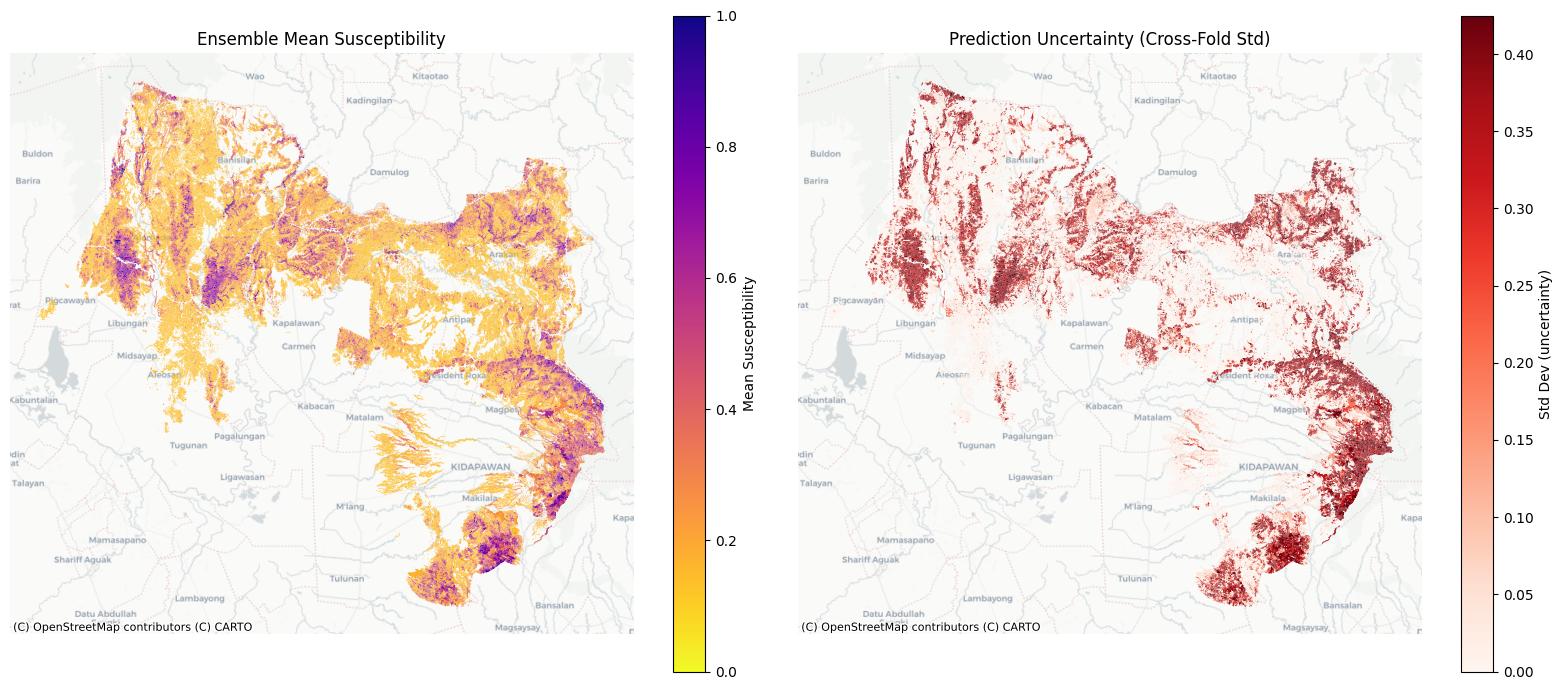

In [ ]:
# Ensemble uncertainty map
from py_files.metrics import fold_ensemble_uncertainty


mean_sus, std_sus = fold_ensemble_uncertainty(fold_susceptibilities)
print(f"Ensemble mean susceptibility: {mean_sus.mean():.4f} +/- {std_sus.mean():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

df_wm = validation_df.to_crs(epsg=3857)
df_wm['ensemble_mean'] = mean_sus
df_wm['ensemble_std'] = std_sus

norm_sus = mcolors.Normalize(vmin=0, vmax=1.0)
df_wm.plot(column='ensemble_mean', cmap='plasma_r', norm=norm_sus, ax=axes[0],
           legend=True, legend_kwds={'label': 'Mean Susceptibility'})
cx.add_basemap(axes[0], crs=df_wm.crs.to_string(), source=cx.providers.CartoDB.Positron)
axes[0].set_title('Ensemble Mean Susceptibility')
axes[0].set_axis_off()

norm_std = mcolors.Normalize(vmin=0, vmax=std_sus.max())
df_wm.plot(column='ensemble_std', cmap='Reds', norm=norm_std, ax=axes[1],
           legend=True, legend_kwds={'label': 'Std Dev (uncertainty)'})
cx.add_basemap(axes[1], crs=df_wm.crs.to_string(), source=cx.providers.CartoDB.Positron)
axes[1].set_title('Prediction Uncertainty (Cross-Fold Std)')
axes[1].set_axis_off()

fig.tight_layout()
plt.show()